# ASU Source Decoded ROOT Hitmap

Read the decoded-frame ROOT file, draw the ROOT hitmap and the `hitsHistogram.txt` hitmap, and print a compact consistency check.

In [13]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import uproot

In [14]:
RUN_DIR = Path("/home/llr/ilc/shi/data/SiWECAL-Prototype/TB2026-06/Comission/source_asu/source-ASU-2026_008_run_000002")
ROOT_FILE = RUN_DIR / "converted_source-ASU-2026_008_run_000002.dat.root"
HITS_TXT = RUN_DIR / "hitsHistogram.txt"
MAPPING_PATH = Path("/home/llr/ilc/shi/code/TB_2026_6/Decode/mapping/fev11_cob_rotate_chip_channel_x_y_mapping.txt")
BRANCH = "hitbit_high"
SLAB_INDEX = 0
BRANCH_SHAPE = (15, 16, 15, 64)

print(f"ROOT file: {ROOT_FILE}")
print(f"hits txt : {HITS_TXT}")

ROOT file: /home/llr/ilc/shi/data/SiWECAL-Prototype/TB2026-06/Comission/source_asu/source-ASU-2026_008_run_000002/converted_source-ASU-2026_008_run_000002.dat.root
hits txt : /home/llr/ilc/shi/data/SiWECAL-Prototype/TB2026-06/Comission/source_asu/source-ASU-2026_008_run_000002/hitsHistogram.txt


In [15]:
def parse_hits_histogram(path: Path) -> np.ndarray:
    hits = np.zeros((16, 64), dtype=np.int64)
    pattern = re.compile(
        r"SkirocIndex\s+(\d+)\s+ChipId\s+(\d+)\s+Channel\s+(\d+)\s+"
        r"TotalNbOfHits\s+(\d+)"
    )
    for line in path.read_text(errors="replace").splitlines():
        match = pattern.search(line)
        if match:
            _, chip, channel, count = map(int, match.groups())
            hits[chip, channel] += count
    return hits


def count_root_hits(root_path: Path, branch_name: str, slab_index: int) -> tuple[np.ndarray, int]:
    hits = np.zeros((16, 64), dtype=np.int64)
    with uproot.open(root_path) as root_file:
        tree = root_file["siwecaldecoded"]
        branch = tree[branch_name]
        for basket_index in range(branch.num_baskets):
            entry_start, entry_stop = branch.basket_entry_start_stop(basket_index)
            basket_entries = int(entry_stop - entry_start)
            data = np.frombuffer(branch.basket(basket_index).data, dtype=">i4")
            values = data.reshape((basket_entries,) + BRANCH_SHAPE)
            hits += (values[:, slab_index, :, :, :] == 1).sum(axis=(0, 2))
    return hits, tree.num_entries


def load_mapping(path: Path) -> dict[tuple[int, int], tuple[float, float]]:
    rows = np.genfromtxt(path, names=True)
    return {
        (int(row["chip"]), int(row["channel"])): (float(row["x"]), float(row["y"]))
        for row in rows
    }


def chip_channel_to_xy(values: np.ndarray, mapping: dict[tuple[int, int], tuple[float, float]]):
    xs = sorted({xy[0] for xy in mapping.values()})
    ys = sorted({xy[1] for xy in mapping.values()})
    x_index = {x: i for i, x in enumerate(xs)}
    y_index = {y: i for i, y in enumerate(ys)}
    grid = np.full((len(ys), len(xs)), np.nan)
    for chip in range(16):
        for channel in range(64):
            x, y = mapping[(chip, channel)]
            grid[y_index[y], x_index[x]] = values[chip, channel]
    return grid, xs, ys

In [16]:
txt_hits = parse_hits_histogram(HITS_TXT)
root_hits, n_entries = count_root_hits(ROOT_FILE, BRANCH, SLAB_INDEX)
diff = root_hits - txt_hits

print(f"entries: {n_entries}")
print(f"txt_total_hits: {int(txt_hits.sum())}")
print(f"root_total_hits: {int(root_hits.sum())}")
print(f"n_mismatched_channels: {int(np.count_nonzero(diff))}")
print(f"max_abs_diff: {int(np.max(np.abs(diff)))}")

entries: 6173
txt_total_hits: 1387555
root_total_hits: 1388477
n_mismatched_channels: 933
max_abs_diff: 2


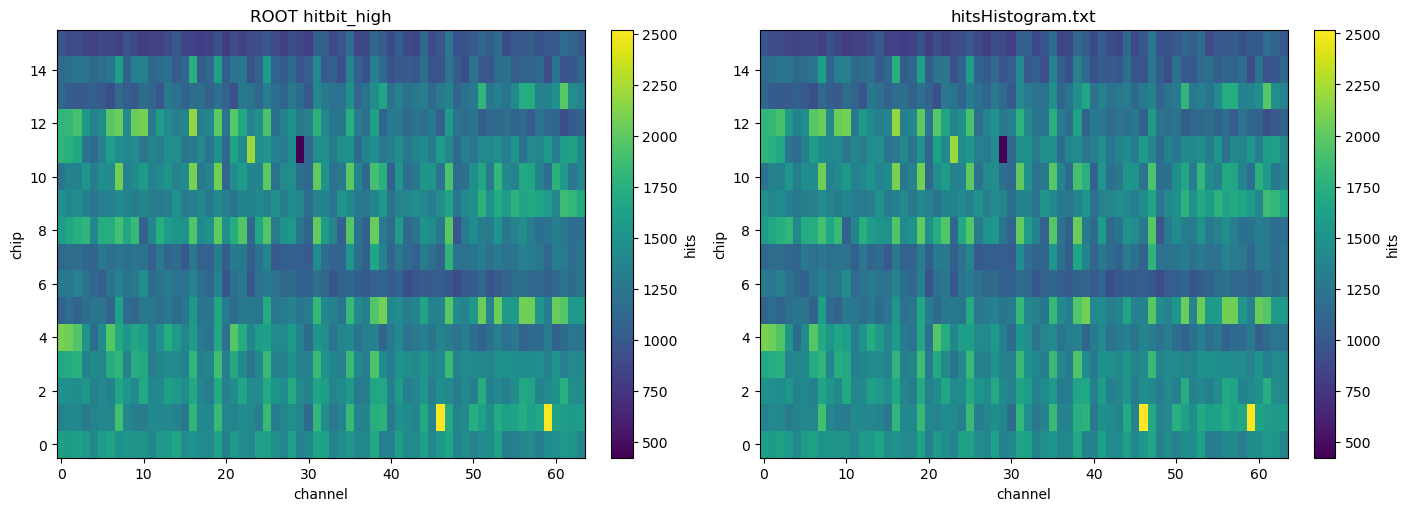

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, values, title in [
    (axes[0], root_hits, f"ROOT {BRANCH}"),
    (axes[1], txt_hits, "hitsHistogram.txt"),
]:
    image = ax.imshow(values, origin="lower", aspect="auto", interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("channel")
    ax.set_ylabel("chip")
    fig.colorbar(image, ax=ax, label="hits")
plt.show()

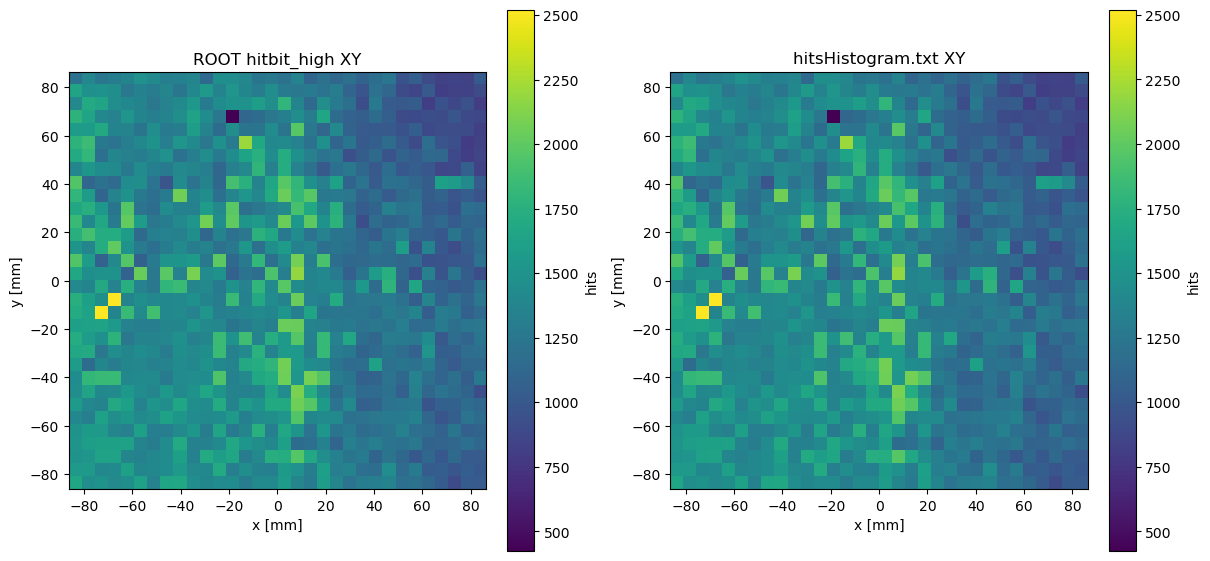

In [18]:
mapping = load_mapping(MAPPING_PATH)
root_xy, xs, ys = chip_channel_to_xy(root_hits, mapping)
txt_xy, _, _ = chip_channel_to_xy(txt_hits, mapping)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True)
for ax, values, title in [
    (axes[0], root_xy, f"ROOT {BRANCH} XY"),
    (axes[1], txt_xy, "hitsHistogram.txt XY"),
]:
    image = ax.imshow(
        values,
        origin="lower",
        interpolation="nearest",
        extent=[min(xs), max(xs), min(ys), max(ys)],
        aspect="equal",
    )
    ax.set_title(title)
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")
    fig.colorbar(image, ax=ax, label="hits")
plt.show()